<a href="https://colab.research.google.com/github/IraSamsonova/nn/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os
import matplotlib.pyplot as plt

# Создаем папку для сохранения изображений
os.makedirs('./gan_output', exist_ok=True)

# Выбор устройства: GPU если доступен, иначе CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")


Используемое устройство: cuda


In [2]:
# Гиперпараметры
BATCH_SIZE = 128
LATENT_DIM = 100   # Размер латентного пространства
HIDDEN_DIM = 256   # Размер скрытых слоев
LEARNING_RATE = 0.0002
EPOCHS = 200
SAMPLE_INTERVAL = 10   # Сохранять изображения каждые 10 эпох

# Размер изображения MNIST
IMG_DIM = 28 * 28

# Трансформации вектора [0,1] в [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загружаем MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [3]:
# Инициализация весов
def init_weights(m):
    if isinstance(m, nn.Linear): # полносвязный ли слой
        nn.init.normal_(m.weight, 0.0, 0.02)  # случайная инициализация весов с нормальным распределением с mean=0, srd=0.02
        if m.bias is not None:
            nn.init.constant_(m.bias, 0) # все смещения в ноль


In [5]:
# Генератор
class GAN_Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__() # инициализирует родительский класс nn.Module
        self.model = nn.Sequential(
            nn.Linear(latent_dim, HIDDEN_DIM), # преобразует z
            nn.BatchNorm1d(HIDDEN_DIM), # нормализует батч по mean, std
            nn.ReLU(),

            nn.Linear(HIDDEN_DIM, HIDDEN_DIM * 2),
            nn.BatchNorm1d(HIDDEN_DIM * 2),
            nn.ReLU(),

            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM * 4),
            nn.BatchNorm1d(HIDDEN_DIM * 4),
            nn.ReLU(),

            nn.Linear(HIDDEN_DIM * 4, output_dim),
            nn.Tanh()  # выход в [-1, 1]
        )
        self.apply(init_weights) # инициализация весов

    def forward(self, z):
        return self.model(z) # возвращает сгенерированное изображение


In [6]:
# Дискриминатор
class GAN_Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, HIDDEN_DIM * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(HIDDEN_DIM * 4, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(HIDDEN_DIM, 1),
            nn.Sigmoid()  # oграничивает выход в диапазоне [0,1]
        )
        self.apply(init_weights)

    def forward(self, img):
        return self.model(img) # вероятность [0,1], что изображение реальное


In [7]:
# создаёт генератор и дискриминатор
generator = GAN_Generator(LATENT_DIM, IMG_DIM).to(device)
discriminator = GAN_Discriminator(IMG_DIM).to(device)

criterion = nn.BCELoss()  # разница между прогнозом дискриминатора и правильной меткой

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

# 16 фиксированных векторов шума для визуализации прогресса
fixed_noise = torch.randn(16, LATENT_DIM).to(device)


In [8]:
# сохранение сгенерированных изображений
def save_generated(epoch, generator, noise):
    generator.eval() # режим оценки
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)
        fake_images = fake_images * 0.5 + 0.5  # денормализация [-1,1] в [0,1]
        save_image(fake_images, f'./gan_output/epoch_{epoch:03d}.png', nrow=4)
    generator.train() # возврат генератора в режим обучения


In [10]:
# Обучение GAN
G_losses = []
D_losses = []

print("Начало обучения GAN...")

for epoch in range(EPOCHS):
    for batch_idx, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images = real_images.view(batch_size, -1).to(device)

        # Метки для реальных и фейковых изображений
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Дискриминатор
        discriminator.zero_grad()
        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_images = generator(noise).detach() # генератор заморожен
        output_fake = discriminator(fake_images)
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Генератор
        generator.zero_grad()
        noise = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_images = generator(noise)
        output = discriminator(fake_images)
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizer_G.step()

        # Сохраняем статистику
        if batch_idx % 50 == 0:
            G_losses.append(loss_G.item())
            D_losses.append(loss_D.item())

    # Сохраняем изображения каждые SAMPLE_INTERVAL эпох
    if epoch % SAMPLE_INTERVAL == 0 or epoch == EPOCHS - 1:
        save_generated(epoch, generator, fixed_noise)
        print(f"[Epoch {epoch}/{EPOCHS}] Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}")

print("Обучение завершено!")


Начало обучения GAN...
[Epoch 0/200] Loss_D: 1.1092, Loss_G: 1.3067
[Epoch 10/200] Loss_D: 1.2887, Loss_G: 0.7448
[Epoch 20/200] Loss_D: 1.3661, Loss_G: 0.7281
[Epoch 30/200] Loss_D: 1.3303, Loss_G: 0.6969
[Epoch 40/200] Loss_D: 1.3835, Loss_G: 0.7501
[Epoch 50/200] Loss_D: 1.3636, Loss_G: 0.6938
[Epoch 60/200] Loss_D: 1.3855, Loss_G: 0.7245
[Epoch 70/200] Loss_D: 1.3775, Loss_G: 0.7087
[Epoch 80/200] Loss_D: 1.3716, Loss_G: 0.6929
[Epoch 90/200] Loss_D: 1.3584, Loss_G: 0.7247
[Epoch 100/200] Loss_D: 1.3865, Loss_G: 0.7011
[Epoch 110/200] Loss_D: 1.3537, Loss_G: 0.6984
[Epoch 120/200] Loss_D: 1.3921, Loss_G: 0.6963
[Epoch 130/200] Loss_D: 1.3666, Loss_G: 0.6980
[Epoch 140/200] Loss_D: 1.3744, Loss_G: 0.7259
[Epoch 150/200] Loss_D: 1.3797, Loss_G: 0.6739
[Epoch 160/200] Loss_D: 1.3768, Loss_G: 0.7290
[Epoch 170/200] Loss_D: 1.3928, Loss_G: 0.7140
[Epoch 180/200] Loss_D: 1.3702, Loss_G: 0.7294
[Epoch 190/200] Loss_D: 1.4066, Loss_G: 0.6932
[Epoch 199/200] Loss_D: 1.3669, Loss_G: 0.7291
О

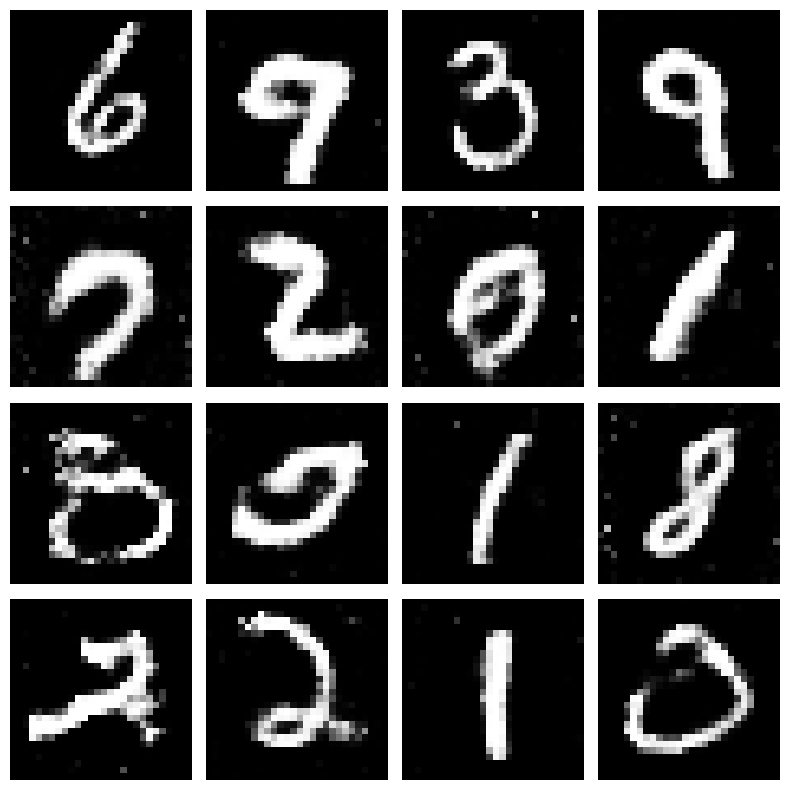

In [12]:
generator.eval()
with torch.no_grad():
    test_noise = torch.randn(16, LATENT_DIM).to(device) # создаём 16 случайных латентных векторов
    generated_images = generator(test_noise).view(-1, 28, 28).cpu()
    generated_images = (generated_images + 1) / 2  # денормализация

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
